In [1]:
import pandas as pd

X = pd.read_csv('../data/raw/heart_disease_features.csv')
y = pd.read_csv('../data/raw/heart_disease_target.csv')

print(X.shape, y.shape)
print(X.head())
print(X.info())
print(y['num'].value_counts())


(303, 13) (303, 1)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  
0  0.0   6.0  
1  3.0   3.0  
2  2.0   7.0  
3  0.0   3.0  
4  0.0   3.0  
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64 

In [2]:
print(X.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64


In [3]:
# Going to merge X and y

df = X.copy()
df['target'] = y['num'].apply(lambda x: 1 if x > 0 else 0) # bianrizing here itself

In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


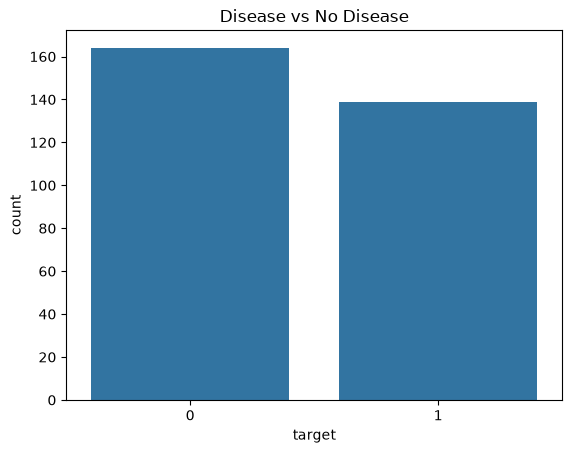

In [5]:
# class balance
import matplotlib.pyplot as plt 
import seaborn as sns

sns.countplot(data=df, x='target')
plt.title("Disease vs No Disease")
plt.show()


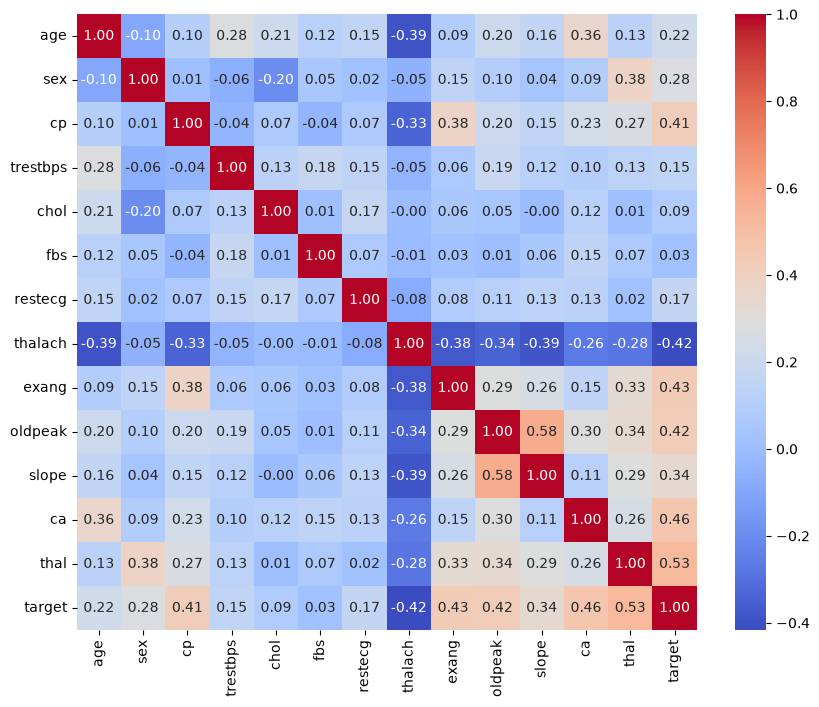

In [6]:
# co-relation with target - heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.show()

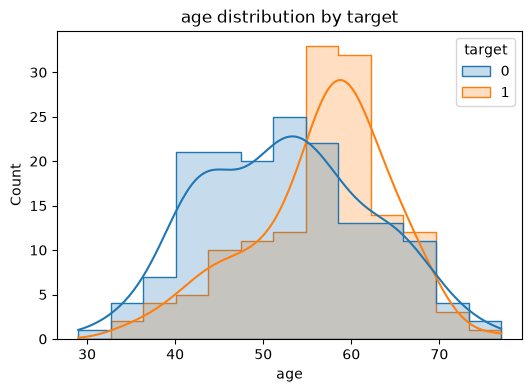

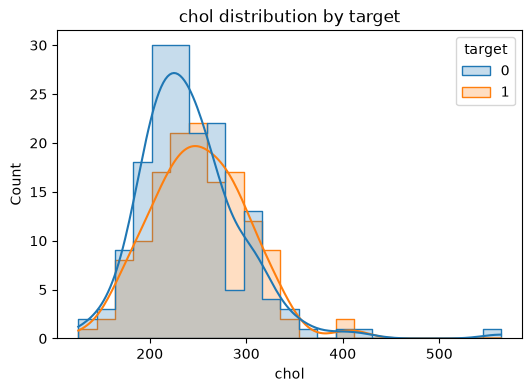

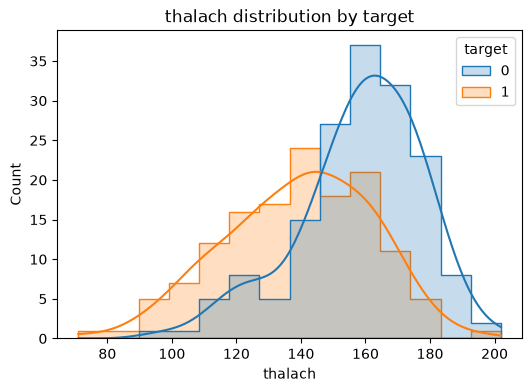

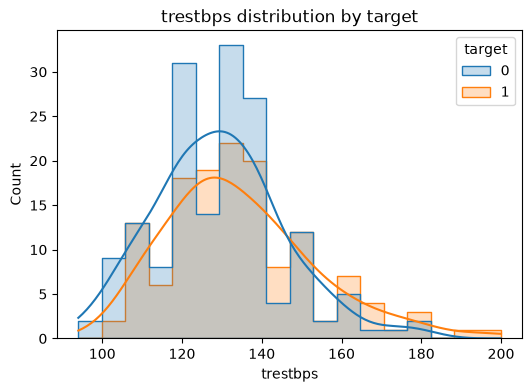

In [7]:
# Distribution split by target

for col in ['age', 'chol', 'thalach', 'trestbps']:
    plt.figure(figsize=(6,4))
    sns.histplot(data=df, x=col, hue='target', kde=True, element='step')
    plt.title(f'{col} distribution by target')
    plt.show()

In [9]:
print(f"Before: {df.shape[0]} rows")
df_clean = df.dropna(subset=['ca', 'thal'])
print(f"After: {df_clean.shape[0]} rows")

Before: 303 rows
After: 297 rows


In [ ]:
# scaling
df_clean['target'] = df_clean['target'].apply(lambda x: 1 if x > 0 else 0)

print(df_clean['target'].value_counts()) # prints 0 and 1 in target now
print(f"\nDisease Prevalence: {df_clean['target'].mean():.2%}") # 

target
0    160
1    137
Name: count, dtype: int64

Disease Prevalence: 46.13%
